In [1]:
import numpy as np
import torch
import pandas as pd
import h5py
from src.interpolate import shift_spectra_linear

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Style académique type A&A/ApJ
mpl.rcParams.update(
    {
        # --- Texte & police ---
        "text.usetex": True,  # active LaTeX
        "font.family": "serif",  # police avec empattements
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        # --- Axes & ticks ---
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        # --- Légende ---
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.framealpha": 0.9,
        "legend.fancybox": False,  # cadre rectangulaire
        # --- Figure & sauvegarde ---
        "figure.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.dpi": 300,
        "savefig.format": "pdf",  # export vectoriel par défaut
    }
)

# Style de fond : blanc minimaliste
plt.style.use("default")


In [16]:
dset_soap = np.load(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/npz_datasets/plot_dataset.npz",
)

soap_wavegrid = dset_soap["wavegrid"]
soap_spectra = dset_soap["spectra"]
soap_activity = dset_soap["activity"]
soap_template = dset_soap["template"]

dset_soap_ccf = np.load(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/npz_datasets/plot_dataset_ccf.npz",
)

# Contexte scientifique

### Plot d'un spectre

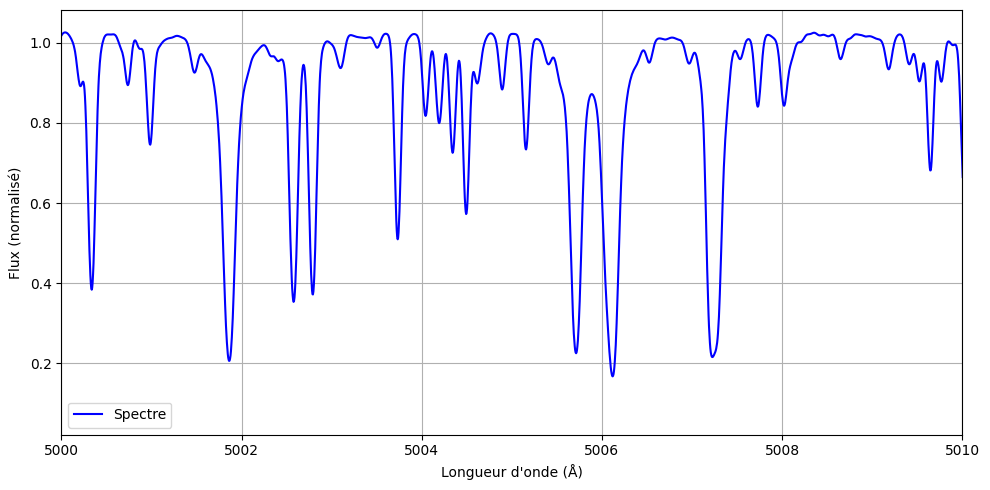

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_spectra[0, :], label="Spectre", color="blue")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5000, 5010)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/spectrum_example.png",
    dpi=300,
)
plt.show()

In [5]:
t_velocity = torch.tensor([3000]).unsqueeze(0)
t_spectrum = torch.tensor(soap_spectra[0, :]).unsqueeze(0)
t_wavegrid = torch.tensor(soap_wavegrid).unsqueeze(0)

shifted_spectrum = shift_spectra_linear(
    spectra=t_spectrum,
    velocities=t_velocity,
    wavegrid=t_wavegrid
)

shifted_spectrum = shifted_spectrum.squeeze(0).detach().numpy()

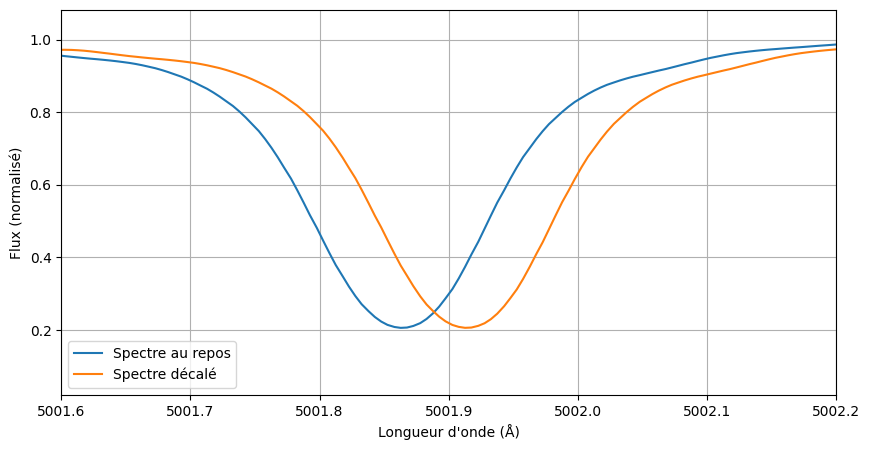

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_spectra[0, :], label="Spectre au repos")
plt.plot(soap_wavegrid, shifted_spectrum, label="Spectre décalé")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.6, 5002.2)
plt.grid()
plt.legend()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/doppler_shift.png",
    dpi=300,
)
plt.show()

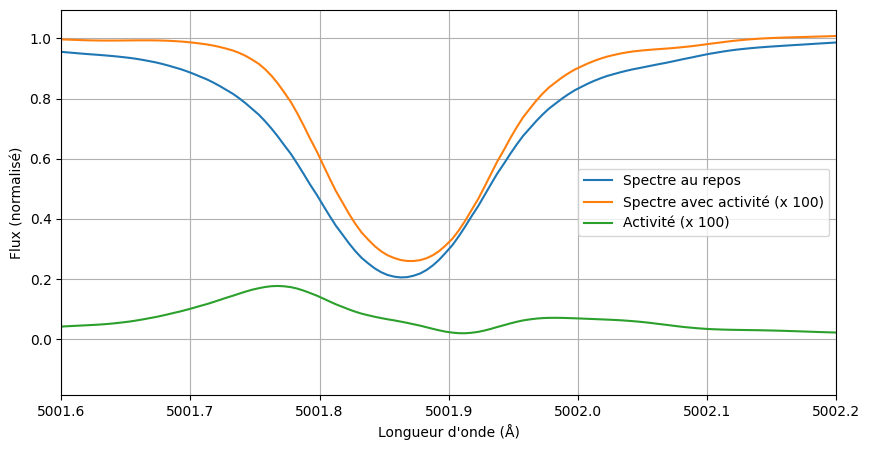

In [7]:

plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_template, label="Spectre au repos")
plt.plot(soap_wavegrid, soap_template + soap_activity[0, :] * 100, label="Spectre avec activité (x 100)")
plt.plot(
    soap_wavegrid, soap_activity[0, :] * 100, label="Activité (x 100)"
)

plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.6, 5002.2)
plt.grid()
plt.legend()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/activite.png",
    dpi=300,
)
plt.show()


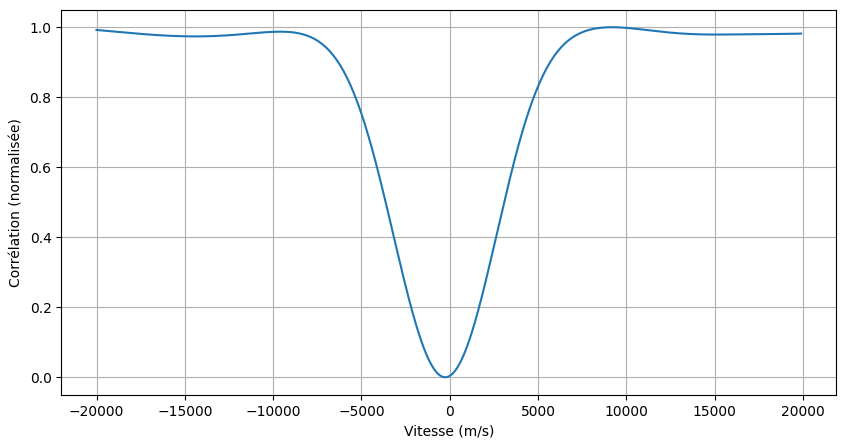

In [ ]:
from src.ccf import compute_CCFs

v_grid = np.arange(-20000, 20000, 100)

ccfs = compute_CCFs(
    spectra=dset_soap_ccf["spectra"][0, :][None, :],
    wavegrid=dset_soap_ccf["wavegrid"],
    v_grid=v_grid,
    window_size_velocity=820,
)

plt.figure(figsize=(10, 5))
plt.plot(v_grid, ccfs[0, :], label="Spectre 1")
plt.xlabel("Vitesse (m/s)")
plt.ylabel("Corrélation (normalisée)")
plt.grid()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/ccf_example.png",
    dpi=300,
)
plt.show()